In [1]:
from pathlib import Path
import sys
import pandas as pd

PROJECT_ROOT = Path("~/UNSW-MRes/MRes/seacofs_eddy_dataset_modular").expanduser()

SRC = PROJECT_ROOT / "src"
if str(SRC) not in sys.path:
    sys.path.insert(0, str(SRC))

from seacofs_eddy_dataset.config import load_config

CONFIG_PATH = PROJECT_ROOT / "config" / "local.yaml"
config = load_config(CONFIG_PATH)


In [4]:
files = sorted((config.output_root / "detections").glob("*.parquet"))

df_nenc = pd.concat(
    [pd.read_parquet(f) for f in files],
    ignore_index=True
)

df_nenc

,Day,nxc,nyc,Cyc,nic,njc,fnumber
0,1462,830.0,1515.0,AE,245,307,1461
1,1462,358.0,1408.0,AE,136,285,1461
2,1462,928.0,1356.0,CE,261,274,1461
3,1462,506.0,1354.0,CE,179,274,1461
4,1462,754.0,1285.0,AE,231,260,1461
...,...,...,...,...,...,...,...
414944,10650,349.0,158.0,AE,133,32,10641
414945,10650,973.0,126.0,CE,268,26,10641
414946,10650,805.0,95.0,AE,240,19,10641
414947,10650,157.0,34.0,CE,57,7,10641


In [5]:
files = sorted((config.output_root / "surface_eddies").glob("*.parquet"))

df_doppio = pd.concat(
    [pd.read_parquet(f) for f in files],
    ignore_index=True
)

df_doppio

,Day,fnumber,nxc,nyc,nCyc,nic,njc,xc,yc,w,q11,q12,q22,Omega0,Omega,Rc,psi0,R
0,1462,1461,830.0,1515.0,AE,245,307,829.879126,1515.297884,0.000016,0.705472,-0.172995,1.459911,0.000007,0.000008,93.406313,-37.010850,63.384028
1,1462,1461,358.0,1408.0,AE,136,285,357.902634,1407.794571,0.000032,1.252542,-0.373183,0.909563,0.000015,0.000014,77.893592,-41.235849,50.068171
2,1462,1461,928.0,1356.0,CE,261,274,928.181752,1356.070550,-0.000011,0.918433,-0.656814,1.558529,-0.000004,-0.000007,108.660559,42.689603,74.597458
3,1462,1461,506.0,1354.0,CE,179,274,505.750855,1353.499933,-0.000032,1.091520,-0.174833,0.944157,-0.000016,-0.000014,103.202167,72.408844,69.457705
4,1462,1461,754.0,1285.0,AE,231,260,753.849693,1284.689807,0.000022,1.300245,-0.375378,0.877456,0.000010,0.000009,91.462547,-38.743359,65.961546
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
414944,10650,10641,349.0,158.0,AE,133,32,348.663439,158.138527,0.000033,1.386381,0.046491,0.722862,0.000016,0.000013,92.830954,-56.075977,43.099927
414945,10650,10641,973.0,126.0,CE,268,26,978.294053,127.970950,-0.000004,0.623332,-0.550205,2.089938,-0.000001,-0.000002,54.863438,2.414418,34.482872
414946,10650,10641,805.0,95.0,AE,240,19,804.765913,95.382012,0.000011,1.261992,0.398050,0.917949,0.000005,0.000006,63.420966,-11.382331,45.893895
414947,10650,10641,157.0,34.0,CE,57,7,157.210669,33.449590,-0.000007,0.987434,0.628993,1.413393,-0.000003,-0.000004,78.527179,12.307057,34.764443


In [6]:
files = sorted((config.output_root / "tracked").glob("*.parquet"))

df_tracked = pd.concat(
    [pd.read_parquet(f) for f in files],
    ignore_index=True
)

df_tracked

,Day,fnumber,nxc,nyc,nCyc,nic,njc,xc,yc,w,...,Omega,Rc,psi0,R,err,Omega0_abs,Cyc,eddy_idx,Eddy,next_num
0,1462,1461,464.0,12.0,CE,168,2,465.706536,12.356764,-0.000008,...,-0.000003,87.044833,11.370690,23.891213,1.743430,0.000004,CE,0,1,74229
1,1462,1461,821.0,40.0,AE,243,8,819.018694,39.922959,0.000012,...,0.000004,37.302443,-3.055685,22.267177,1.982803,0.000005,AE,1,2,74229
2,1462,1461,238.0,40.0,CE,90,8,236.631876,41.645583,-0.000011,...,-0.000005,60.052648,9.238973,38.586312,2.140024,0.000005,CE,2,3,74229
3,1462,1461,534.0,58.0,CE,186,12,536.350493,56.939256,-0.000010,...,-0.000005,45.768796,5.030901,39.213234,2.578759,0.000004,CE,3,4,74229
4,1462,1461,365.0,59.0,AE,139,12,365.341748,58.118367,0.000025,...,0.000010,54.864001,-14.423765,34.395704,0.945552,0.000011,AE,4,5,74229
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
364706,10650,10641,470.0,1243.0,AE,170,252,467.469965,1246.267909,0.000034,...,0.000008,58.042004,-13.854877,32.104207,4.132833,0.000012,AE,22,74227,74229
364707,10650,10641,277.0,1266.0,CE,105,256,276.540248,1265.812188,-0.000016,...,-0.000006,60.969740,11.861518,38.503683,0.496634,0.000007,CE,23,74167,74229
364708,10650,10641,207.0,1273.0,AE,77,258,205.771657,1285.150974,0.000021,...,0.000007,46.091506,-7.207823,39.148432,12.212903,0.000005,AE,24,74228,74229
364709,10650,10641,320.0,1451.0,AE,122,294,319.928166,1451.113459,0.000033,...,0.000012,114.739891,-77.910685,46.062907,0.134287,0.000015,AE,25,74061,74229


In [7]:
df_processed = pd.read_parquet(
    config.output_root / "processed" / "eddy_dataset_processed.parquet"
)

df_processed

,Eddy,Day,Cyc,lon,lat,ic,jc,xc,yc,w,...,q11,q12,q22,Rc,psi0,AR,R,Age,Date,fname
0,1,1462,CE,152.716333,-38.866383,171,26,474.560686,127.605656,-0.000034,...,1.758660,-0.532719,0.737370,31.455845,6.679024,1.973172,20.004291,28,1994-01-02,/srv/scratch/z3533156/26year_BRAN2020/outer_av...
1,1,1463,CE,152.836206,-38.814279,173,28,482.821993,136.635735,-0.000038,...,1.617876,-0.538331,0.816358,32.700506,8.298263,1.859668,18.906549,28,1994-01-03,/srv/scratch/z3533156/26year_BRAN2020/outer_av...
2,1,1464,CE,152.905198,-38.816261,175,28,488.606048,138.480541,-0.000038,...,1.393129,-0.557491,0.967292,29.703325,7.116866,1.745185,20.859920,28,1994-01-04,/srv/scratch/z3533156/26year_BRAN2020/outer_av...
3,1,1465,CE,152.719389,-38.902070,171,25,475.960098,123.953440,-0.000020,...,1.129925,-0.374295,1.051020,30.687659,7.199754,1.433213,18.674495,28,1994-01-05,/srv/scratch/z3533156/26year_BRAN2020/outer_av...
4,1,1466,CE,152.753007,-38.935135,172,25,479.803789,121.483614,-0.000030,...,1.026354,-0.135421,1.060328,31.671992,7.282641,1.140614,21.564028,28,1994-01-06,/srv/scratch/z3533156/26year_BRAN2020/outer_av...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
162636,3983,10646,CE,155.134295,-40.092889,223,14,711.617369,69.895295,-0.000013,...,1.184753,-0.030921,0.903800,59.890634,10.838993,1.148690,54.275882,22,2019-02-24,/srv/scratch/z3533156/26year_BRAN2020/outer_av...
162637,3983,10647,CE,154.883954,-40.396445,221,6,699.853461,30.349325,-0.000007,...,0.948719,-0.199901,1.216728,66.476449,11.586931,1.253634,46.817975,22,2019-02-25,/srv/scratch/z3533156/26year_BRAN2020/outer_av...
162638,3983,10648,CE,155.001742,-40.518521,223,4,713.016589,20.865525,-0.000007,...,0.877251,-0.200469,1.267517,73.062265,12.334870,1.306102,46.695383,22,2019-02-26,/srv/scratch/z3533156/26year_BRAN2020/outer_av...
162639,3983,10649,CE,155.187153,-40.282064,225,10,721.413917,51.393389,-0.000009,...,0.867521,-0.100735,1.276832,79.648080,13.082809,1.241162,47.190073,22,2019-02-27,/srv/scratch/z3533156/26year_BRAN2020/outer_av...


In [16]:
df_processed.Age.max()

np.int64(463)

(array([18370., 21711., 20634., 17432., 14843., 11451., 13216., 14703.,
        16398., 13883.]),
 array([3.18054647e-01, 1.56441902e+02, 3.12565750e+02, 4.68689597e+02,
        6.24813445e+02, 7.80937292e+02, 9.37061140e+02, 1.09318499e+03,
        1.24930884e+03, 1.40543268e+03, 1.56155653e+03]),
 <BarContainer object of 10 artists>)

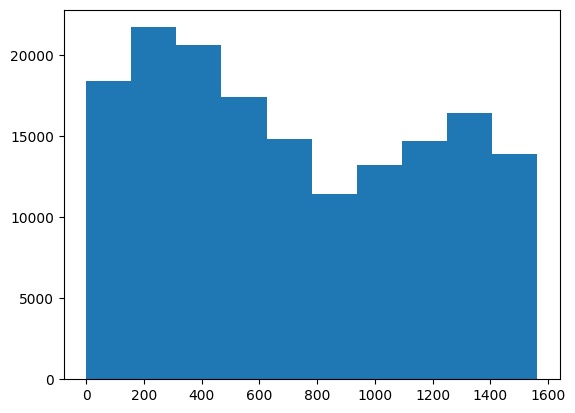

In [14]:
import matplotlib.pyplot as plt
plt.hist(df_processed.yc)